# Analytical Energy Landscapes for Multi-agent Path Finding

1/25, Michael Fatemi

In [2]:
%load_ext autoreload
%autoreload 2

import sys

from pathlib import Path

path = Path("..").resolve().as_posix()
if str(path) not in sys.path:
    sys.path.insert(0, str(path))

## Kinetic Energy Landscape

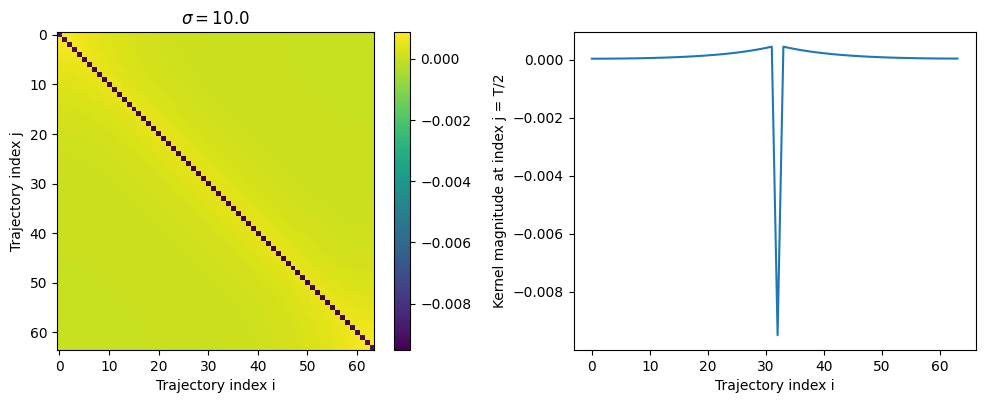

In [13]:
import numpy as np
import matplotlib.pyplot as plt

N = 64
velocity_kernel = np.zeros((N - 1, N))
velocity_kernel[:, 1:] = np.eye(N - 1)
velocity_kernel -= np.eye(N - 1, N)
K = velocity_kernel.T @ velocity_kernel
sigma_B = 10.0

score_kernel = -np.linalg.inv(K + np.eye(N) / (sigma_B**2)) @ K / (sigma_B**2)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title(f"$\\sigma = {sigma_B}$")
plt.imshow(score_kernel)
plt.xlabel("Trajectory index i")
plt.ylabel("Trajectory index j")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.plot(score_kernel[N // 2])
plt.xlabel("Trajectory index i")
plt.ylabel("Kernel magnitude at index j = T/2")

plt.tight_layout()
plt.show()


In [4]:
import time
from ael.agent_obstacle_score import (
    compute_agent_obstacle_score,
    compute_agent_obstacle_score_batched,
    compute_agent_obstacle_distance_batched,
    compute_r1_r2_batched,
)
import matplotlib.patches as patches

## Approach 1 for computing obstacle-based energy landscape

Here, I try direct integration. However, I don't think this approach is very feasible.


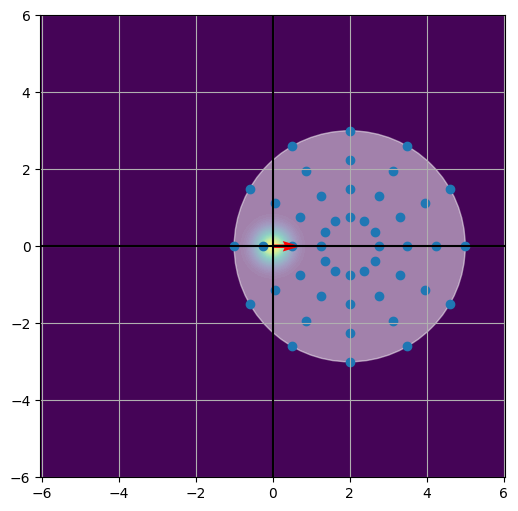

In [5]:
c_x = 2
R: float = 3

plt.figure(figsize=(6, 6))
plt.axis("equal")

# Color according to Gaussian.
gaussian_xx, gaussian_yy = np.meshgrid(
    np.linspace(-6, 6, 128),
    np.linspace(-6, 6, 128),
)
sigma_B = 0.3
gaussian_probability = (
    1
    / (2 * np.pi * sigma_B**2)
    * np.exp(-0.5 * (gaussian_xx**2 + gaussian_yy**2) / sigma_B**2)
)
plt.contourf(gaussian_xx, gaussian_yy, gaussian_probability, levels=50)
# plt.xlim(-6, 6)
plt.ylim(-6, 6)

plt.gca().axvline(x=0, color="k")
plt.gca().axhline(y=0, color="k")
plt.grid()
plt.gca().add_patch(patches.Circle((c_x, 0), R, fill=True, color="white", alpha=0.5))

N_segments = 12
angles = np.linspace(0, 2 * np.pi, N_segments, endpoint=False)
x = R * np.column_stack([np.cos(angles), np.sin(angles)])
evaluation_locations = np.concatenate([x, x * 0.75, x * 0.5, x * 0.25])
evaluation_locations[:, 0] += c_x
plt.scatter(evaluation_locations[:, 0], evaluation_locations[:, 1])

gaussian_evaluations = np.exp(
    -0.5
    * (evaluation_locations[:, 0] ** 2 + evaluation_locations[:, 1] ** 2)
    / sigma_B**2
)
gaussian_first_moment = (gaussian_evaluations[:, None] * evaluation_locations).sum(
    axis=0
)
denominator_B = gaussian_evaluations.sum()

displacement_direction = -1 / (2 * sigma_B**2) * gaussian_first_moment / denominator_B

plt.quiver(
    0, 0, displacement_direction[0], displacement_direction[1], color="red", scale=5
)

plt.show()

## Approach 2 for computing obstacle energy landscape

This approach is also numerical, but in terms of a much more precise integral.


In [1]:
import pandas as pd
from IPython.display import display

data = {
    "c_x": [],
    "obs_rad": [],
    "displacement": [],
}

plt.figure(figsize=(12, 12))

i = 1
for obs_rad_B in [0.1, 0.2, 0.5]:
    for c_x in [0.8, 0.6, 0.4]:
        plt.subplot(3, 3, i)
        i += 1

        plt.title(f"Distance to object: {c_x:.1f}")

        agent_x = 0
        agent_y = 0
        # obs_x = 0
        # obs_y = c_x
        obs_x = np.sqrt(2)/2 * c_x
        obs_y = np.sqrt(2)/2 * c_x

        # if obs_rad != 1 or c_x != 0.5:
        #     continue

        R = obs_rad_B

        # Color according to Gaussian.
        square_size = 5
        gaussian_xx, gaussian_yy = np.meshgrid(
            np.linspace(-square_size, square_size, 128),
            np.linspace(-square_size, square_size, 128),
        )
        sigma_B = 1.0
        gaussian_probability = (
            1
            / (2 * np.pi * sigma_B**2)
            * np.exp(-0.5 * (gaussian_xx**2 + gaussian_yy**2) / sigma_B**2)
        )
        plt.contourf(gaussian_xx, gaussian_yy, gaussian_probability, levels=50)

        plt.gca().axvline(x=0, color="k")
        plt.gca().axhline(y=0, color="k")
        plt.grid()
        plt.gca().add_patch(
            patches.Circle((obs_x, obs_y), R, fill=True, color="white", alpha=0.5)
        )
        plt.gca().add_patch(
            patches.Circle((agent_x, agent_y), sigma_B, fill=True, color="white", alpha=0.5)
        )

        t0 = time.time()
        displacement_direction = compute_agent_obstacle_score(
            0, 0, obs_x, obs_y, R, sigma_B, n_integral=200
        )
        t1 = time.time()

        data['c_x'].append(c_x)
        data['obs_rad'].append(R)
        data['displacement'].append(displacement_direction[0])

        plt.quiver(
            0,
            0,
            displacement_direction[0],
            displacement_direction[1],
            color="red",
            scale=1,
        )
        plt.axis("equal")

        plt.xlim(-square_size + 3, square_size - 3)
        plt.ylim(-square_size + 3, square_size - 3)

display(pd.DataFrame(data))

plt.tight_layout()
plt.show()



NameError: name 'plt' is not defined

0.7627141549633578 0.3608108011062512 0.3903835584436493
0.7627141549633626 0.3608108011062512 0.3903835584436493
[-0.01311239 -0.03440313] [-0.01311239 -0.03440313]


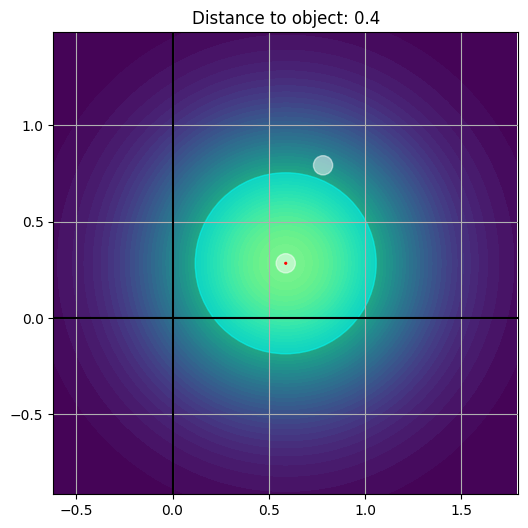

In [85]:
plt.figure(figsize=(6, 6))
plt.title(f"Distance to object: {c_x:.1f}")

# agent_x = 0.08
# agent_y = -0.11
# obs_x = 0.782
# obs_y = 0.793
# obs_rad_B = 0.05
# R = obs_rad_B

# agent_x = 0.5054223744292239
# agent_y = 0.2875570776255709
# obs_x = 0.782
# obs_y = 0.793
# sigma = 0.47005208333333
# obs_rad = 0.05
# agent_rad = 0.05


agent_x = 0.588
agent_y = 0.284
obs_x = 0.782
obs_y = 0.793
sigma = 0.47005208333333
obs_rad = 0.05
agent_rad = 0.05

# Color according to Gaussian.
square_size = 1.2
gaussian_xx, gaussian_yy = np.meshgrid(
    np.linspace(-square_size, square_size, 128) + agent_x,
    np.linspace(-square_size, square_size, 128) + agent_y,
)
gaussian_probability = (
    1
    / (2 * np.pi * sigma**2)
    * np.exp(-0.5 * ((gaussian_xx - agent_x)**2 + (gaussian_yy - agent_y)**2) / sigma**2)
)
plt.contourf(gaussian_xx, gaussian_yy, gaussian_probability, levels=50)

plt.gca().axvline(x=0, color="k")
plt.gca().axhline(y=0, color="k")
plt.grid()
plt.gca().add_patch(
    patches.Circle((obs_x, obs_y), obs_rad, fill=True, color="white", alpha=0.5)
)
plt.gca().add_patch(
    patches.Circle((agent_x, agent_y), sigma, fill=True, color="cyan", alpha=0.5)
)
plt.gca().add_patch(
    patches.Circle((agent_x, agent_y), agent_rad, fill=True, color="white", alpha=0.5)
)

t0 = time.time()
displacement_direction_unbatched = compute_agent_obstacle_score(
    agent_x, agent_y, obs_x, obs_y, obs_rad + agent_rad, sigma, n_integral=20000
)

agent_x_B = np.array([agent_x])
agent_y_B = np.array([agent_y])
obs_x_B = np.array([obs_x])
obs_y_B = np.array([obs_y])
obs_rad_B = np.array([obs_rad + agent_rad])
sigma_B = np.array([sigma])
d_a_o_B = compute_agent_obstacle_distance_batched(
    agent_x_B, agent_y_B, obs_x_B, obs_y_B
)
r1_B, r2_B = compute_r1_r2_batched(obs_rad_B, d_a_o_B)

displacement_direction_batched = compute_agent_obstacle_score_batched(
    agent_x_B, agent_y_B, obs_x_B, obs_y_B, obs_rad_B, sigma_B, r1_B, r2_B, d_a_o_B, n_integral=20000
)[0]
t1 = time.time()

print(displacement_direction_unbatched, displacement_direction_batched)

data['c_x'].append(c_x)
data['obs_rad'].append(R)
data['displacement'].append(displacement_direction_batched[0])

plt.quiver(
    agent_x,
    agent_y,
    displacement_direction_batched[0],
    displacement_direction_batched[1],
    color="red",
    scale=5,
)
plt.axis("equal")
plt.show()

0.2147362232208252


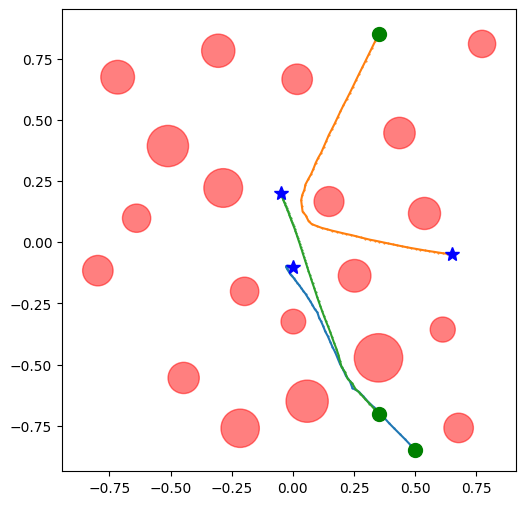

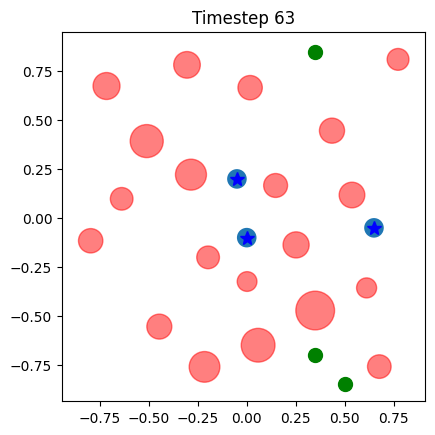

In [283]:
# Implementing Langevin dynamics!
from ael.problem import Problem
from ael.visualize import save_video, visualize, save_optimization_process_video
import json
import numpy as np
from pathlib import Path
from ael.score_function import compute_score

with open("../instances_data/instances_dense.json") as f:
    instances = json.load(f)

instance = instances[0]
start_positions = np.array(instance["agents"]["start_positions"])
end_positions = np.array(instance["agents"]["end_positions"])
obstacle_positions = np.array(instance["obstacles"]["positions"])
obstacle_radii = np.array(instance["obstacles"]["radii"])

problem = Problem.from_json(instance, type="numpy")

# TODO: Initialize from prior distribution based on energy.
trajectory = np.random.randn(64, len(instance["agents"]["start_positions"]), 2) * 0.5
trajectory[0] = start_positions
trajectory[-1] = end_positions

# Use Adam for optimization, optionally.
optimization = "adam"
score_m = np.zeros_like(trajectory)
score_v = np.zeros_like(trajectory)
beta1 = 0.9
beta2 = 0.999
eps = 1e-8
beta1_t = 1.0
beta2_t = 1.0

allow_obstacle_terms = True

schedule = [
    # (sigma, step_size, num_steps, include_obstacles, kinetic_weight)
    # (0.01, 0.2, 1000, True, 5),
    (sigma, 0.5, 60, True, 50)
    for sigma in [0.01, 0.001, 0.001]
]

trajectories = []

t0 = time.time()

global_step = 0
for sigma_B, step_size, num_steps, include_obstacles, kinetic_weight in schedule:
    for i in range(num_steps):
        score = compute_score(
            trajectory,
            sigma=sigma_B,
            problem=problem,
            include_obstacles=include_obstacles,
            n_integral=20,
            kinetic_weight=kinetic_weight,
            magnitude_clip=10000.0,
        )
        beta1_t *= beta1
        beta2_t *= beta2

        if optimization == "sgd":
            trajectory += step_size * score
        else:
            score_m = beta1 * score_m + (1 - beta1) * score
            score_v = beta2 * score_v + (1 - beta2) * (score**2)
            score_m_hat = score_m / (1 - beta1_t)
            score_v_hat = score_v / (1 - beta2_t)
            trajectory += step_size * score_m_hat / (np.sqrt(score_v_hat) + eps)

        trajectory[0] = start_positions
        trajectory[-1] = end_positions
        trajectories.append(trajectory.copy())

        global_step += 1

t1 = time.time()

print(t1 - t0)

trajectories = np.array(trajectories)

plt.figure(figsize=(6, 6))
visualize(problem, plt.gca(), trajectories[-1])
plt.show()

plt.clf()

title = "obstacle_terms_and_adam"

save_optimization_process_video(
    problem,
    trajectories[::10],
    f"{title}_optim.mp4",
)

save_video(problem, trajectories[-1], f"{title}_final_trajectory.mp4")
